Various fun plots and analyses that are interesting but not necessarily part of the main regex work

## Step 1: Loading the data

This should automatically unpack the tarballs if the archive is empty and then check if there are any new circulars to download. If there are, it will download them and repack the archive.

In [1]:
from pathlib import Path
import subprocess
import sys
repo_root = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / "scripts" / "syncCirculars.py").exists()),
    Path.cwd(),
)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

sns.set_theme(style="whitegrid", context="talk")


archive_dir = repo_root / "archive"
output_dir = repo_root / "output"
scripts_dir = repo_root / "scripts"
unpack_script = scripts_dir / "unpackArchive.py"
sync_script = scripts_dir / "syncCirculars.py"

output_dir.mkdir(parents=True, exist_ok=True)

if not archive_dir.exists() or not any(archive_dir.iterdir()):
    if unpack_script.exists():
        print(f"Populating {archive_dir} via {unpack_script}...")
        subprocess.run([sys.executable, str(unpack_script)], cwd=repo_root, check=True)
    else:
        print("scripts/unpackArchive.py not found; cannot populate archive directory.")

print(f"Fetching new circulars from the GCN archive into {archive_dir}...")
subprocess.run(
    [sys.executable, str(sync_script), "--archive_folder", str(archive_dir), "--tarballs_folder", str(output_dir)],
    cwd=repo_root,
    check=True,
)
print("Circular archive sync complete.")

Fetching new circulars from the GCN archive into /Users/tbarna/Documents/GitHub/gcn-regex/archive...
No new circulars downloaded
Archive is up to date.
Circular archive sync complete.


In [2]:
from glob import glob
import json
import re
import matplotlib.pyplot as plt
from collections import Counter
## read in the circulars data from archive folder
circulars = [json.load(open(f, "r")) for f in glob("archive/*.json")]
circulars = {item["circularId"]: item for item in circulars}

for circular in list(circulars.values())[:2]:
    print(json.dumps(circular, indent=4))

{
    "subject": "GRB 210730A: Swift/UVOT Upper Limits",
    "eventId": "GRB 210730A",
    "bibcode": "2021GCN.30552....1K",
    "createdOn": 1627650789000,
    "circularId": 30552,
    "submitter": "Paul Kuin at MSSL  <npkuin@gmail.com>",
    "email": "npkuin@gmail.com",
    "body": "N. P. M. Kuin (UCL-MSSL) and E. Sonbas (Adiyaman Univ.)\nreport on behalf of the Swift/UVOT team:\n\nThe Swift/UVOT began settled observations of the field of GRB 210730A\n90 s after the BAT trigger (Sonbas et al., GCN Circ. 30548).\nNo optical afterglow consistent with the XRT position\n(Beardmore et al. GCN Circ. 30550)\nis detected in the initial UVOT exposures.\nPreliminary 3-sigma upper limits using the UVOT photometric system\n(Breeveld et al. 2011, AIP Conf. Proc. 1358, 373) for the first\nfinding chart (FC) exposure and subsequent exposures are:\n\nFilter         T_start(s)   T_stop(s)      Exp(s)         Mag\n\nwhite_FC            90          204          112         >17.0\nwhite               90

In [3]:
# Keep using the circulars dict loaded above (keyed by circularId).
if isinstance(circulars, list):
    circulars = {item["circularId"]: item for item in circulars}

print(f"Loaded circulars: {len(circulars)}")

Loaded circulars: 45067


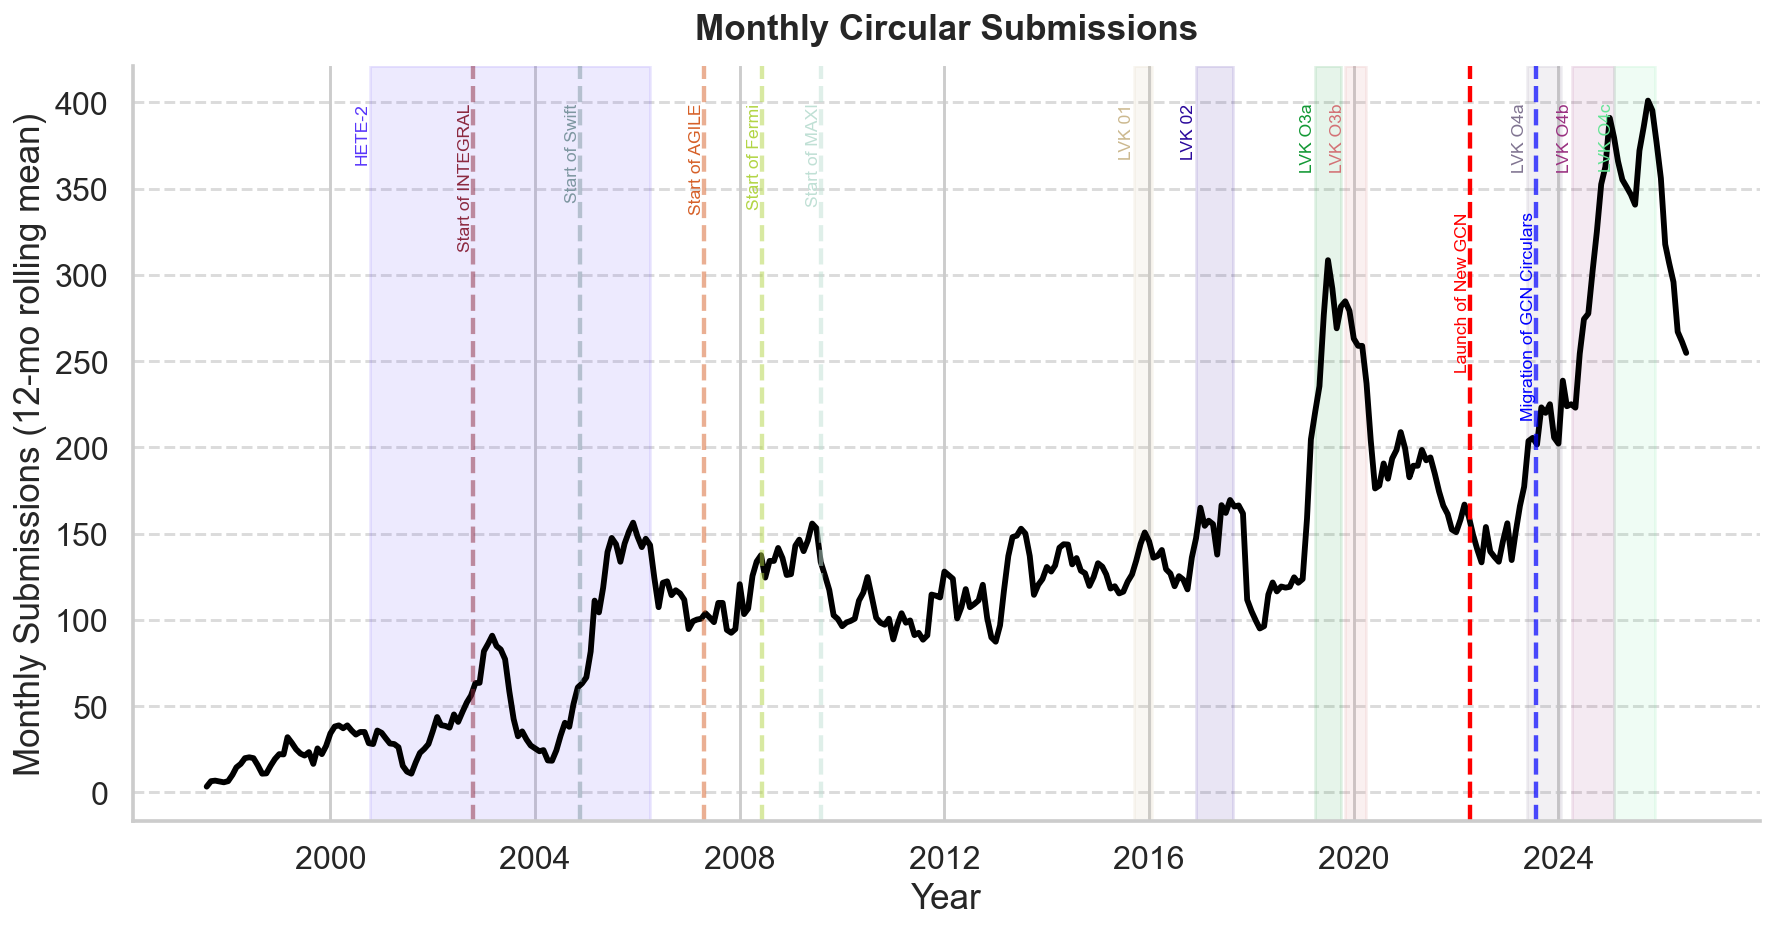

In [10]:
## number of submitted circulars over time
span_or_start = 'span'
circulars_submit_df = pd.DataFrame.from_records(
    (
        {
            "createdOn": circular.get("createdOn"),
            "submittedHow": circular.get("submittedHow") or "email-legacy",
        }
        for circular in circulars.values()
    )
)
fig, ax = plt.subplots(figsize=(15, 7), dpi=140)
circulars_submit_df["month"] = pd.to_datetime(
    circulars_submit_df["createdOn"], unit="ms", errors="coerce"
).dt.to_period("M").dt.to_timestamp()
submit_counts = pd.crosstab(circulars_submit_df["month"], circulars_submit_df["submittedHow"]).sort_index()
submit_counts_total = submit_counts.sum(axis=1)
submit_counts_total_rolling = submit_counts_total.rolling(window=6, min_periods=1, center=True).mean()


ax.set_title("Monthly Circular Submissions", pad=14, weight="bold")
ax.plot(
    submit_counts_total_rolling.index,
    submit_counts_total_rolling.values,
    label="Total",
    linewidth=3,
    color="black",
)

ax.set_xlabel("Year")
ax.set_ylabel("Monthly Submissions (12-mo rolling mean)")
ax.grid(axis='y', linestyle='--', alpha=0.7)
# ax.legend(ncol=2, frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

## Mission spans of launch and end dates (if applicable)
mission_spans = {
    "Swift": (pd.Timestamp("2004-11-20"), None),
    "Fermi": (pd.Timestamp("2008-06-11"), None),
    "INTEGRAL": (pd.Timestamp("2002-10-17"), None),
    "AGILE": (pd.Timestamp("2007-04-23"), None),
    "MAXI": (pd.Timestamp("2009-08-03"), None),
    "HETE-2": (pd.Timestamp("2000-10-09"), pd.Timestamp("2006-03-31")),
    "LVK 01": (pd.Timestamp("2015-09-14"), pd.Timestamp("2016-01-19")),
    "LVK 02": (pd.Timestamp("2016-11-30"), pd.Timestamp("2017-08-25")),
    "LVK O3a": (pd.Timestamp("2019-04-01"), pd.Timestamp("2019-10-01")),
    "LVK O3b": (pd.Timestamp("2019-11-01"), pd.Timestamp("2020-03-27")),
    "LVK O4a": (pd.Timestamp("2023-05-24"), pd.Timestamp("2024-01-16")),
    "LVK O4b": (pd.Timestamp("2024-04-10"), pd.Timestamp("2025-01-28")),
    "LVK O4c": (pd.Timestamp("2025-01-28"), pd.Timestamp("2025-11-18")),
}
if span_or_start == 'span':
    for mission, (start_date, end_date) in mission_spans.items():
        # random color
        color_ = np.random.rand(3,)
        if end_date is None:
            ax.axvline(start_date, color=color_, linestyle="--", alpha=0.5)
        else:
            ax.axvspan(start_date, end_date or pd.Timestamp.now(), color=color_, alpha=0.1)
        text_str = f"Start of {mission}" if end_date is None else f"{mission}"
        ax.text(
            start_date,
            ax.get_ylim()[1] * 0.95,
            text_str,
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=9,  
            color=color_,
        )
elif span_or_start == 'start':
    
    for mission, (start_date, end_date) in mission_spans.items():
        ax.axvline(start_date, color="gray", linestyle="--", alpha=0.5)
        ax.text(
            start_date,
            ax.get_ylim()[1] * 0.95,
            mission,
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=9,
            color="gray",
        )

ax.axvline(pd.Timestamp("2022-04-07"), color="red", linestyle="--", alpha=1)
ax.text(
    pd.Timestamp("2022-04-07"),
    ax.get_ylim()[1] * 0.80,
    "Launch of New GCN",
    rotation=90,
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=9,
    color="red",
)

ax.axvline(pd.Timestamp("2023-07-26"), color="blue", linestyle="--", alpha=0.7)
ax.text(
    pd.Timestamp("2023-07-26"),
    ax.get_ylim()[1] * 0.80,
    "Migration of GCN Circulars",
    rotation=90,
    verticalalignment="top",
    horizontalalignment="right",
    fontsize=9,
    color="blue",
);

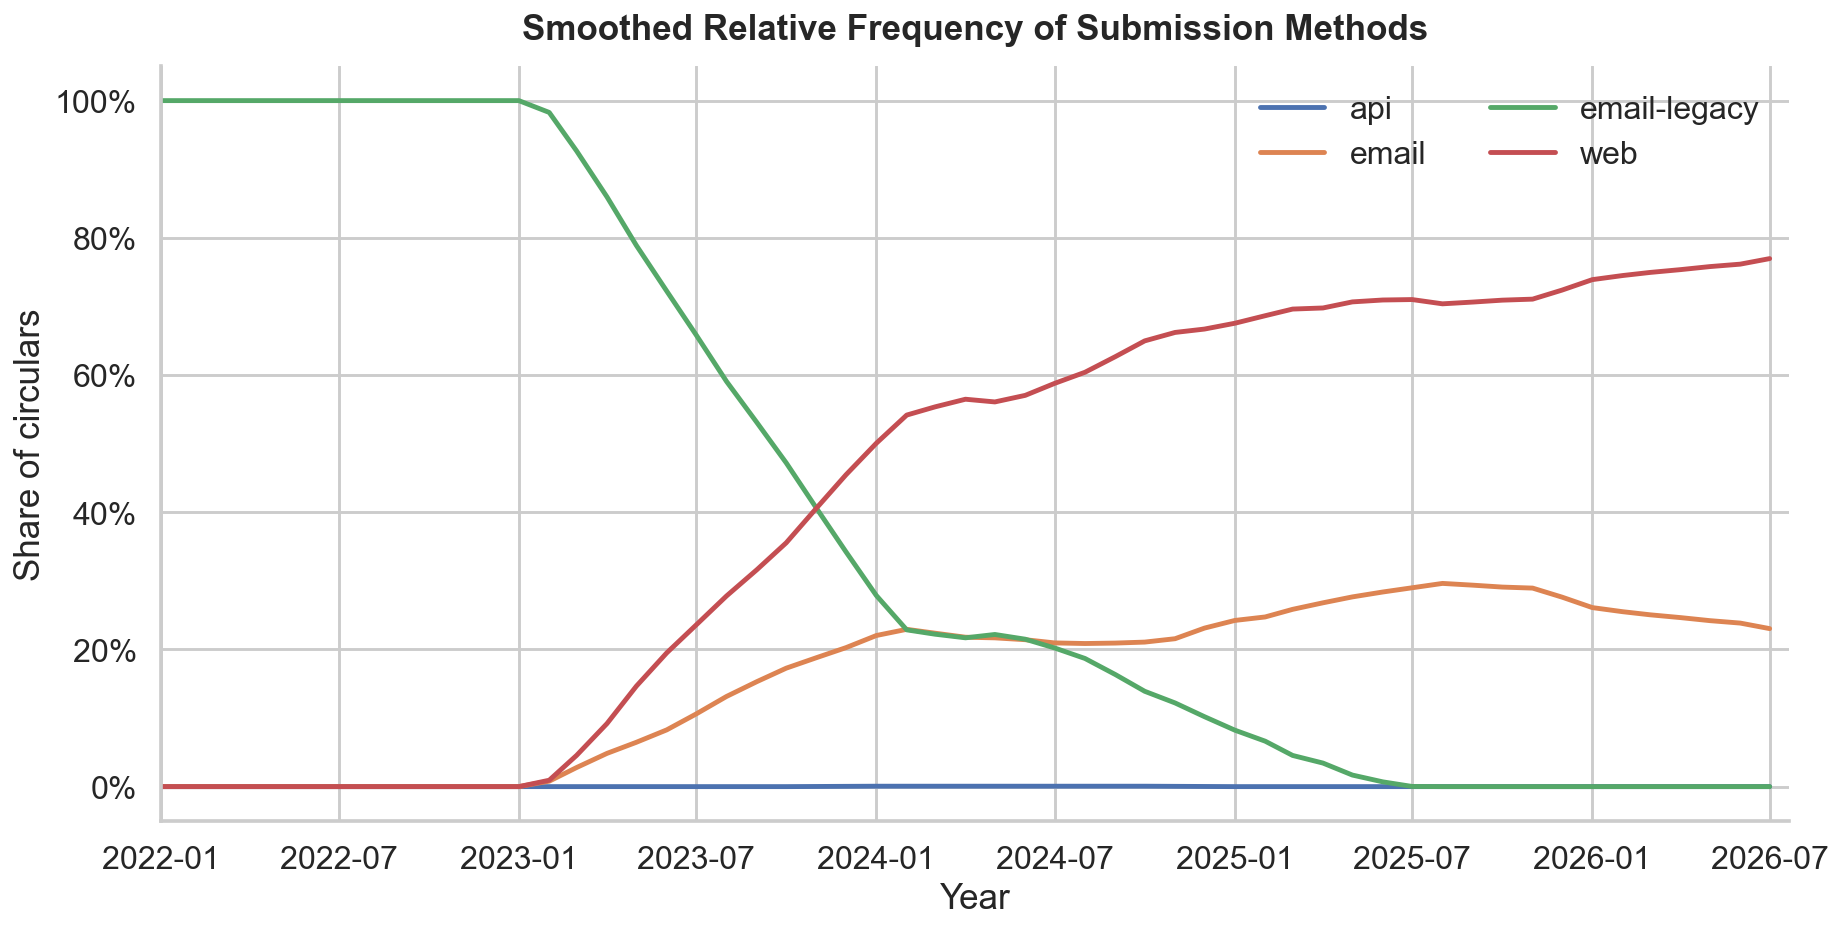

In [11]:
## relative frequency of submission method over time
circulars_submit_df = pd.DataFrame.from_records(
    (
        {
            "createdOn": circular.get("createdOn"),
            "submittedHow": circular.get("submittedHow") or "email-legacy",
        }
        for circular in circulars.values()
    )
)
fig, ax = plt.subplots(figsize=(15, 7), dpi=140)
circulars_submit_df["month"] = pd.to_datetime(
    circulars_submit_df["createdOn"], unit="ms", errors="coerce"
).dt.to_period("M").dt.to_timestamp()
submit_counts = pd.crosstab(circulars_submit_df["month"], circulars_submit_df["submittedHow"]).sort_index()
submit_relative = submit_counts.div(submit_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
submit_relative_smoothed = submit_relative.rolling(window=12, min_periods=1, center=True).mean()

ax.set_title("Smoothed Relative Frequency of Submission Methods", pad=14, weight="bold")
for method in submit_relative_smoothed.columns:
    multiplier = 1 if method == "api" else 1
        
    ax.plot(
        submit_relative_smoothed.index,
        submit_relative_smoothed[method].values * multiplier,  # type: ignore
        label=method if multiplier == 1 else f"{method} (x{multiplier})",
        linewidth=2.5,
    )
ax.set_xlabel("Year")
ax.set_ylabel("Share of circulars")
ax.set_xlim(pd.Timestamp("2022-01-01 00:00:00"), pd.Timestamp.now())
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(ncol=2, frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

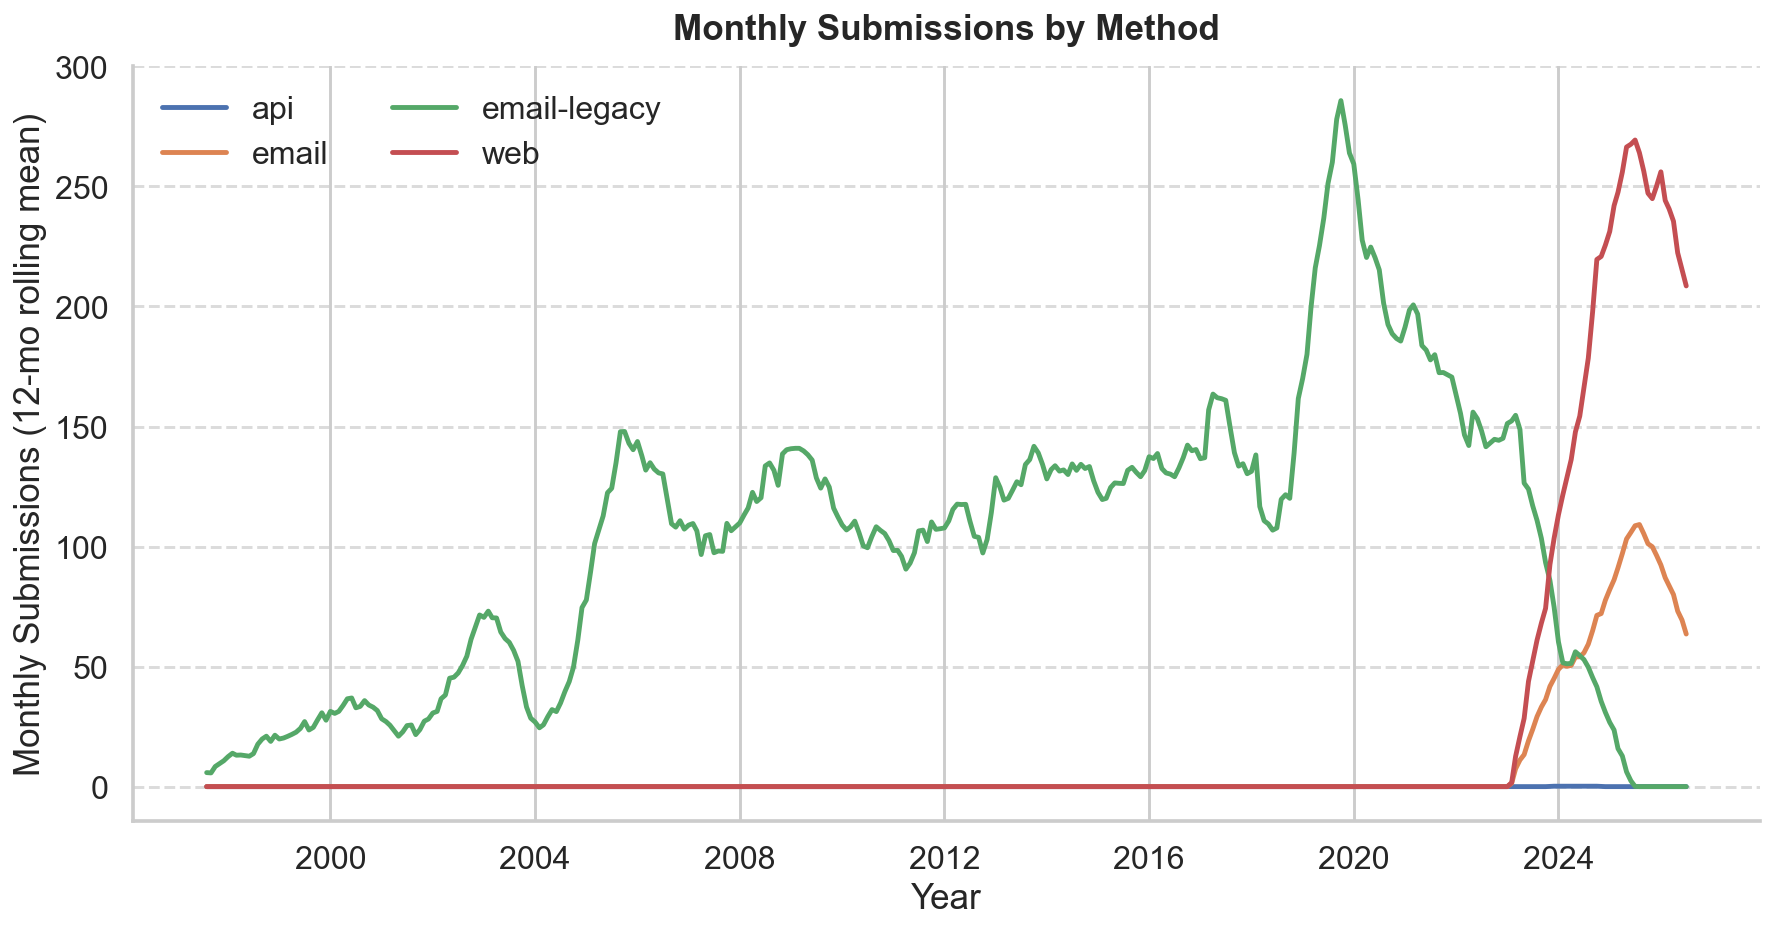

In [12]:
## number of submitted by method over time
circulars_submit_df = pd.DataFrame.from_records(
    (
        {
            "createdOn": circular.get("createdOn"),
            "submittedHow": circular.get("submittedHow") or "email-legacy",
        }
        for circular in circulars.values()
    )
)
fig, ax = plt.subplots(figsize=(15, 7), dpi=140)
circulars_submit_df["month"] = pd.to_datetime(
    circulars_submit_df["createdOn"], unit="ms", errors="coerce"
).dt.to_period("M").dt.to_timestamp()
submit_counts = pd.crosstab(circulars_submit_df["month"], circulars_submit_df["submittedHow"]).sort_index()
submit_absolute = submit_counts.rolling(window=12, min_periods=1, center=True).mean()

ax.set_title("Monthly Submissions by Method", pad=14, weight="bold")
for method in submit_counts.columns:
    multiplier = 1 if method == "api" else 1
        
    ax.plot(
        submit_absolute.index,
        submit_absolute[method].values * multiplier,  # type: ignore
        label=method if multiplier == 1 else f"{method} (x{multiplier})",
        linewidth=2.5,
    )
ax.set_xlabel("Year")
ax.set_ylabel("Monthly Submissions (12-mo rolling mean)")
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(ncol=2, frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

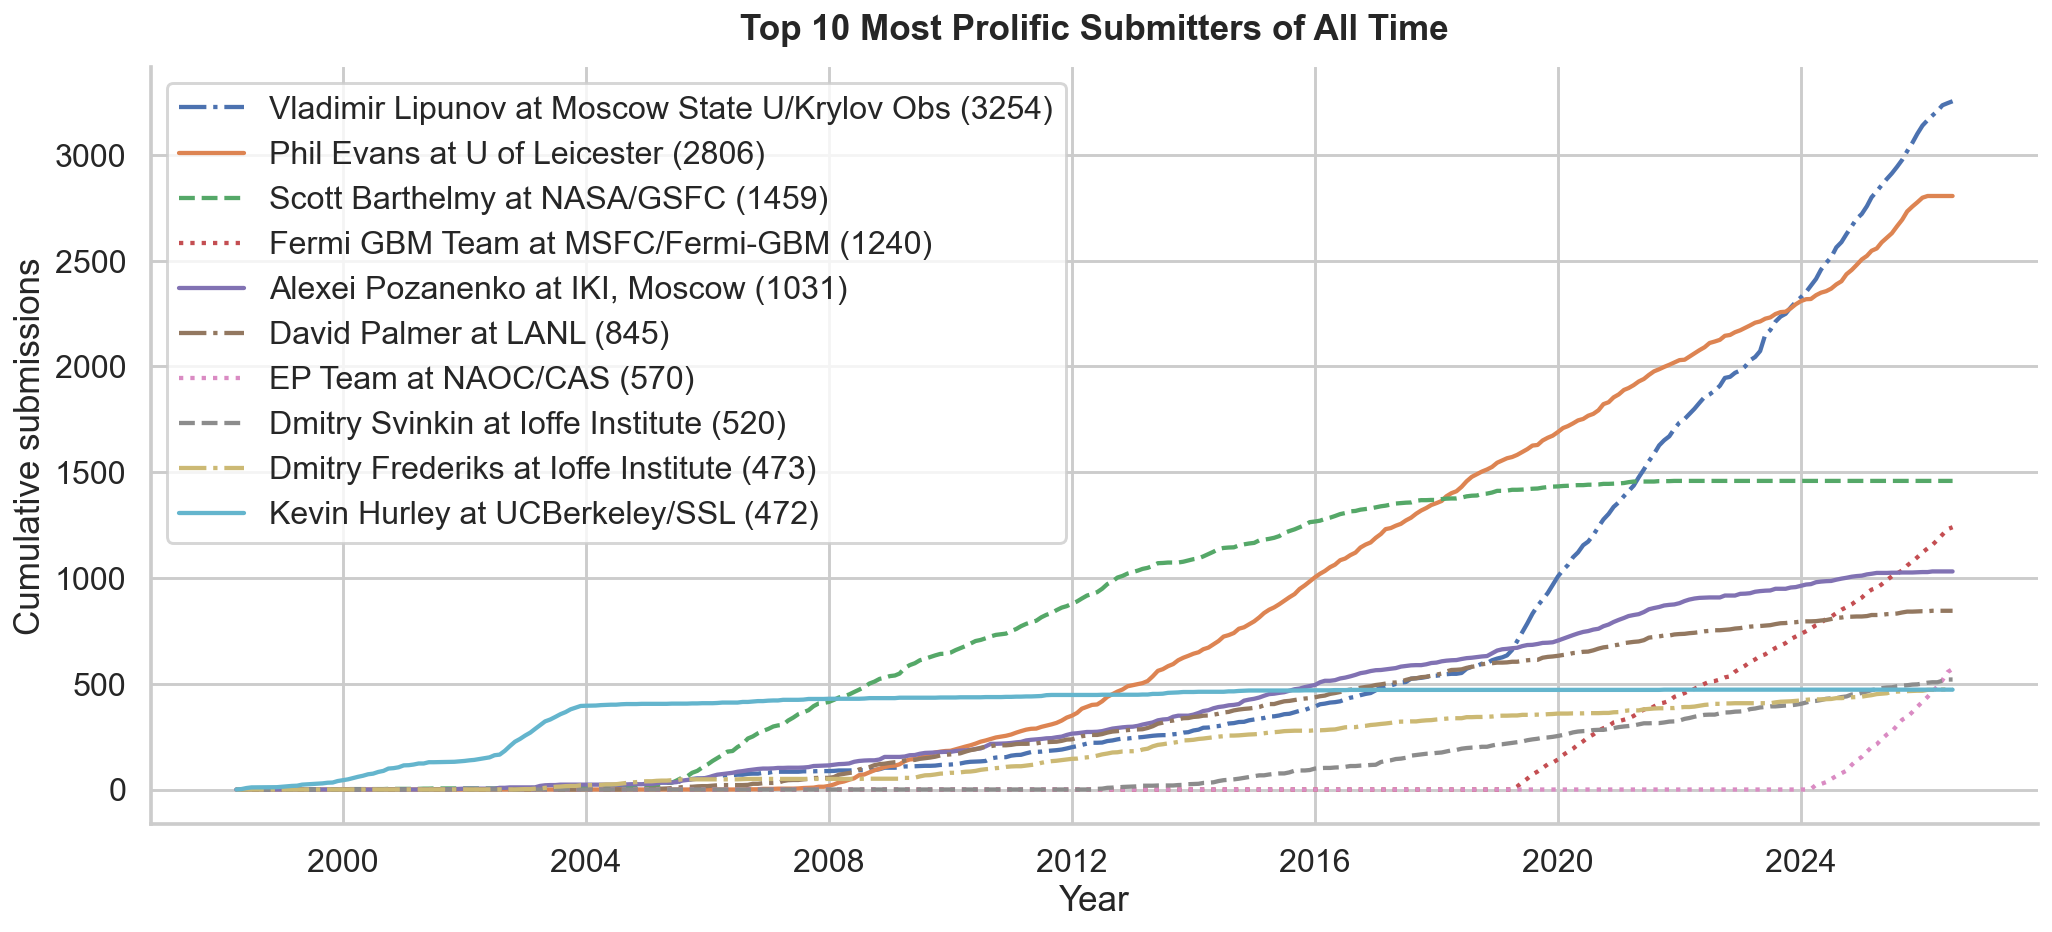

In [7]:
# Most prolific submitters and their submissions over time
top_n_submitters = 10
strip_email = True
def _get_submitter(circ):
    for key in ("submittedBy", "submitter", "submittedUser", "user", "author", "username", "submittedHow"):
        value = circ.get(key)
        if isinstance(value, str) and value.strip():
            if strip_email:
                value_no_email = re.sub(r"<.*?>", "", value)
                return value_no_email.strip()
            return value.strip()
    return "unknown"

submitter_df = pd.DataFrame.from_records(
    (
        {
            "createdOn": circ.get("createdOn"),
            "submitter": _get_submitter(circ),
        }
        for circ in circulars.values()
    )
)

submitter_df["month"] = pd.to_datetime(
    submitter_df["createdOn"], unit="ms", errors="coerce"
).dt.to_period("M").dt.to_timestamp()

submitter_df = submitter_df[submitter_df["month"].notna()].copy()

top_submitters = submitter_df["submitter"].value_counts().head(top_n_submitters)
# print(f"Top {top_n_submitters} submitters:")
# display(top_submitters.to_frame(name="submissions"))

top_names = top_submitters.index.tolist()
monthly_top = (
    submitter_df[submitter_df["submitter"].isin(top_names)]
    .groupby(["month", "submitter"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

cumulative_top = monthly_top.cumsum()

fig, ax = plt.subplots(figsize=(15, 7), dpi=140)
for name in top_names:
    ## random linestyle for each submitter
    linestyle = np.random.choice(['-', '--', '-.', ':',])
    label_with_count = f"{name} ({top_submitters[name]})"
    ax.plot(cumulative_top.index, cumulative_top[name], linewidth=2.2, label=label_with_count, linestyle=linestyle)

ax.set_title(f"Top {top_n_submitters} Most Prolific Submitters of All Time", pad=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative submissions")
ax.legend()#ncol=2, frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

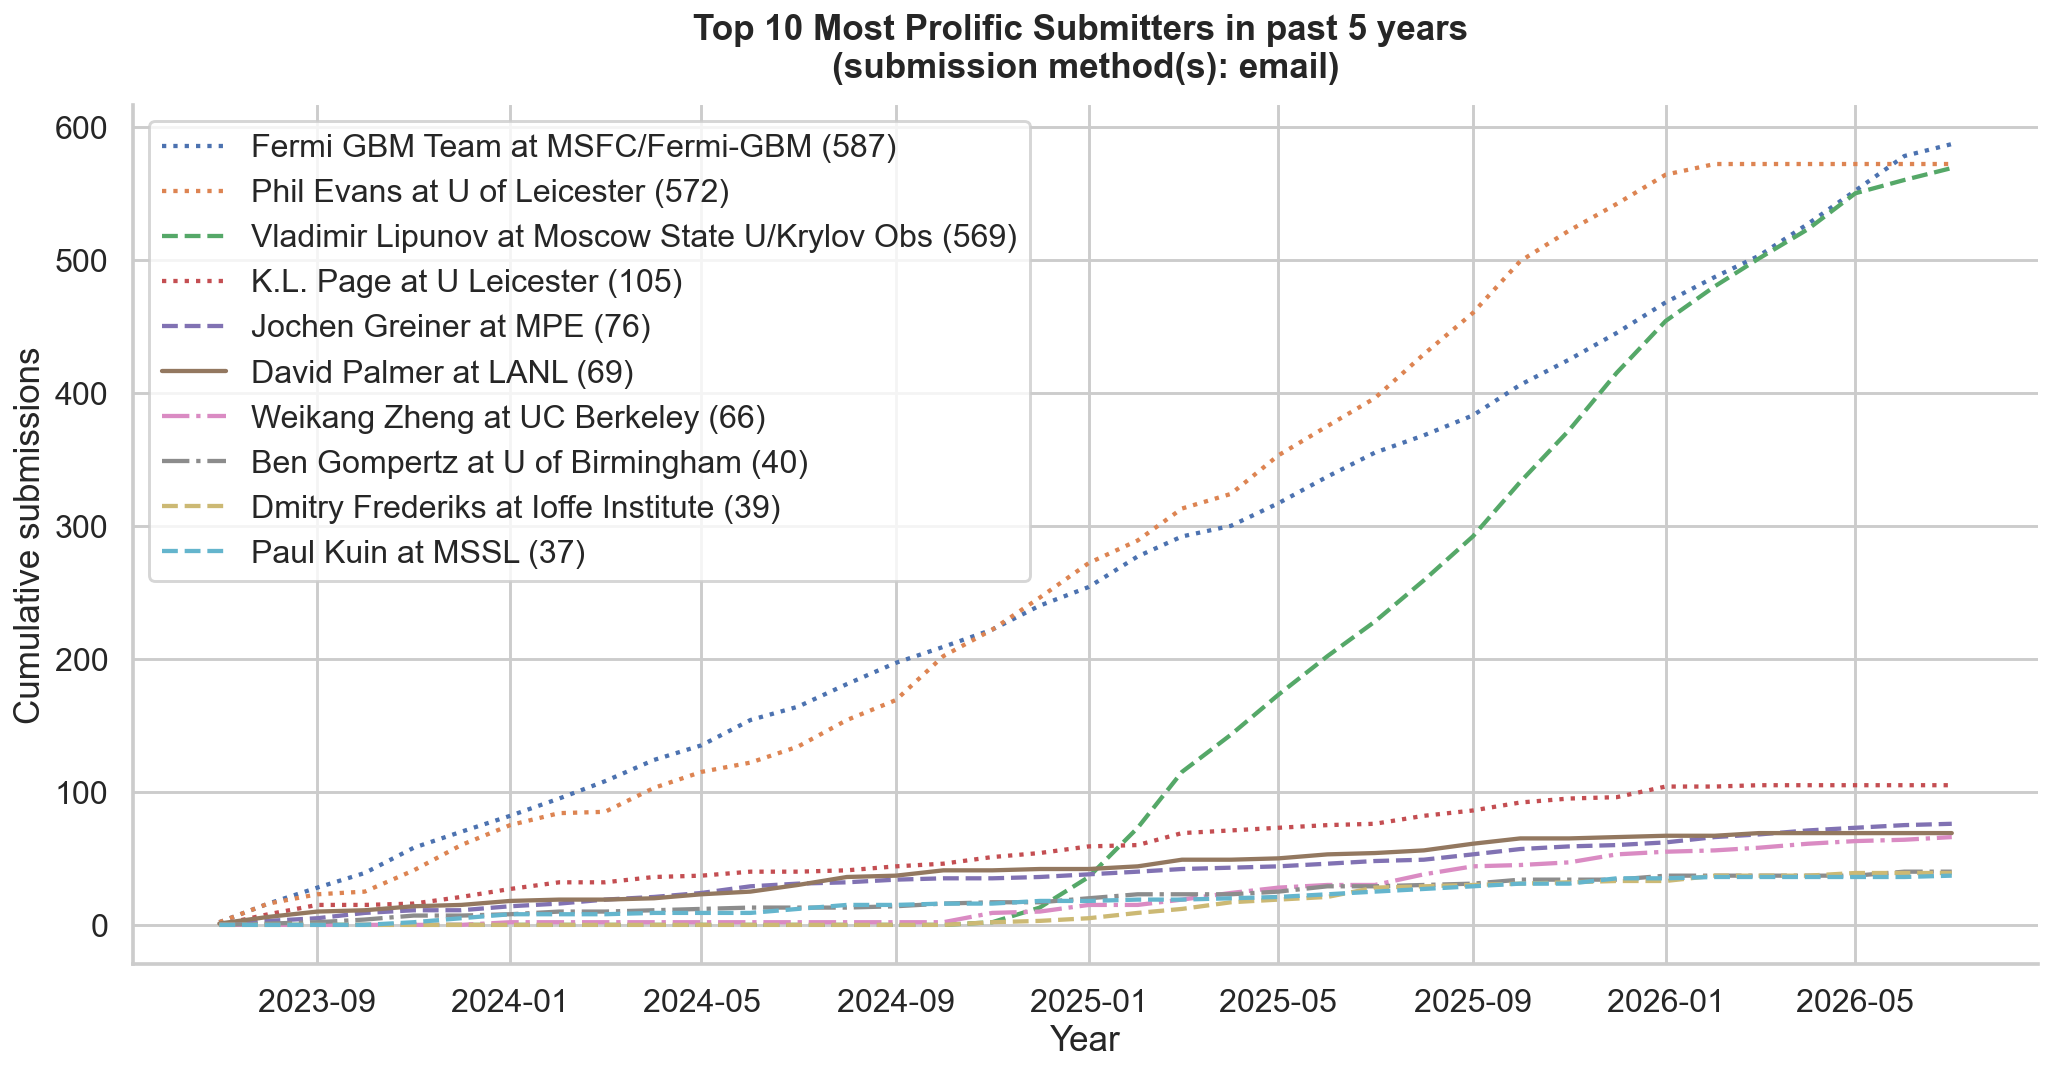

In [8]:
# Most prolific submitters in the past n years
top_n_submitters = 10
past_n_years = 5
strip_email = True
submission_methods = ["email"]
def _get_submitter(circ):
    for key in ("submittedBy", "submitter", "submittedUser", "user", "author", "username", "submittedHow"):
        value = circ.get(key)
        if isinstance(value, str) and value.strip():
            if strip_email:
                value_no_email = re.sub(r"<.*?>", "", value)
                return value_no_email.strip()
            return value.strip()
    return "unknown"

submitter_df = pd.DataFrame.from_records(
    (
        {
            "createdOn": circ.get("createdOn"),
            "submitter": _get_submitter(circ),
            "submittedHow": circ.get("submittedHow") or "email-legacy",
        }
        for circ in circulars.values()
    )
)

submitter_df["month"] = pd.to_datetime(
    submitter_df["createdOn"], unit="ms", errors="coerce"
).dt.to_period("M").dt.to_timestamp()

submitter_df = submitter_df[submitter_df["month"].notna()].copy()

submitter_df["year"] = submitter_df["month"].dt.year
submitter_df = submitter_df[submitter_df["year"] >= (pd.Timestamp.now().year - past_n_years)].copy()

submitter_df = submitter_df[submitter_df["submittedHow"].isin(submission_methods)].copy()

top_submitters = submitter_df["submitter"].value_counts().head(top_n_submitters)
# print(f"Top {top_n_submitters} submitters:")
# display(top_submitters.to_frame(name="submissions"))

top_names = top_submitters.index.tolist()
monthly_top = (
    submitter_df[submitter_df["submitter"].isin(top_names)]
    .groupby(["month", "submitter"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

cumulative_top = monthly_top.cumsum()

fig, ax = plt.subplots(figsize=(15, 8), dpi=140)
for name in top_names:
    ## random linestyle for each submitter
    linestyle = np.random.choice(['-', '--', '-.', ':',])
    label_with_count = f"{name} ({top_submitters[name]})"
    ax.plot(cumulative_top.index, cumulative_top[name], linewidth=2.2, label=label_with_count, linestyle=linestyle)

ax.set_title(f"Top {top_n_submitters} Most Prolific Submitters in past {past_n_years} years \n(submission method(s): {', '.join(submission_methods)})", pad=14, weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative submissions")
ax.legend()#frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()